STEP 1. RFM 분석용 데이터 만들기

1️⃣ 필요한 데이터
	•	transcript (이미 있음)
	•	구매 이벤트: transaction
	•	분석 단위: person

In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

def set_korean_font():
    candidates = [
        "Apple SD Gothic Neo",
        "AppleGothic",
        "NanumGothic",
        "Malgun Gothic",
        "Noto Sans CJK KR",
        "Noto Sans KR"
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            mpl.rcParams["axes.unicode_minus"] = False
            print(f"[OK] font set to: {name}")
            return
    print("[WARN] Korean font not found. Labels may break.")

set_korean_font()

[OK] font set to: Apple SD Gothic Neo


In [13]:


# raw 데이터 로드
profile = pd.read_json("../data/raw/profile.json", orient="records", lines=True)
portfolio = pd.read_json("../data/raw/portfolio.json", orient="records", lines=True)
transcript = pd.read_json("../data/raw/transcript.json", orient="records", lines=True)

print(profile.shape, portfolio.shape, transcript.shape)

(17000, 5) (10, 6) (306534, 4)


In [14]:


# transaction 이벤트만 추출
tx = transcript[transcript["event"] == "transaction"].copy()

# 금액 추출
tx["amount"] = tx["value"].apply(lambda x: x.get("amount") if isinstance(x, dict) else np.nan)

tx.head()

,person,event,value,time,amount
12654,02c083884c7d45b39cc68e1314fec56c,transaction,{'amount': 0.8300000000000001},0,0.83
12657,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,transaction,{'amount': 34.56},0,34.56
12659,54890f68699049c2a04d415abc25e717,transaction,{'amount': 13.23},0,13.23
12670,b2f1cd155b864803ad8334cdf13c4bd2,transaction,{'amount': 19.51},0,19.51
12671,fe97aa22dd3e48c8b143116a8403dd52,transaction,{'amount': 18.97},0,18.97


🚀 STEP 2. Recency / Frequency / Monetary 계산  

1️⃣ 기준 시점(snapshot date) 설정

In [15]:
# 기준 시점 (마지막 거래 시점)
snapshot_time = tx["time"].max()
snapshot_time

714

In [16]:
rfm = (
    tx.groupby("person")
    .agg(
        Recency=("time", lambda x: snapshot_time - x.max()),
        Frequency=("time", "count"),
        Monetary=("amount", "sum")
    )
    .reset_index()
)

rfm.head()

,person,Recency,Frequency,Monetary
0,0009655768c64bdeb2e877511632db8f,18,8,127.60
1,00116118485d4dfda04fdbaba9a87b5c,240,3,4.09
2,0011e0d4e6b944f998e987f904e8c1e5,60,5,79.46
3,0020c2b971eb4e9188eac86d93036a77,6,8,196.86
4,0020ccbbb6d84e358d3414a3ff76cffd,42,12,154.05


	•	Recency: 마지막 구매 이후 경과 시간
→ 작을수록 “최근에 산 고객”  

	•	Frequency: 구매 횟수  

	•	Monetary: 누적 구매 금액

In [17]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,16578.0,85.425262,82.766010,0.00,24.0000,60.00,120.0000,702.00
Frequency,16578.0,8.381771,5.009822,1.00,5.0000,7.00,11.0000,36.00
Monetary,16578.0,107.096874,126.393939,0.05,23.6825,72.41,150.9375,1608.69


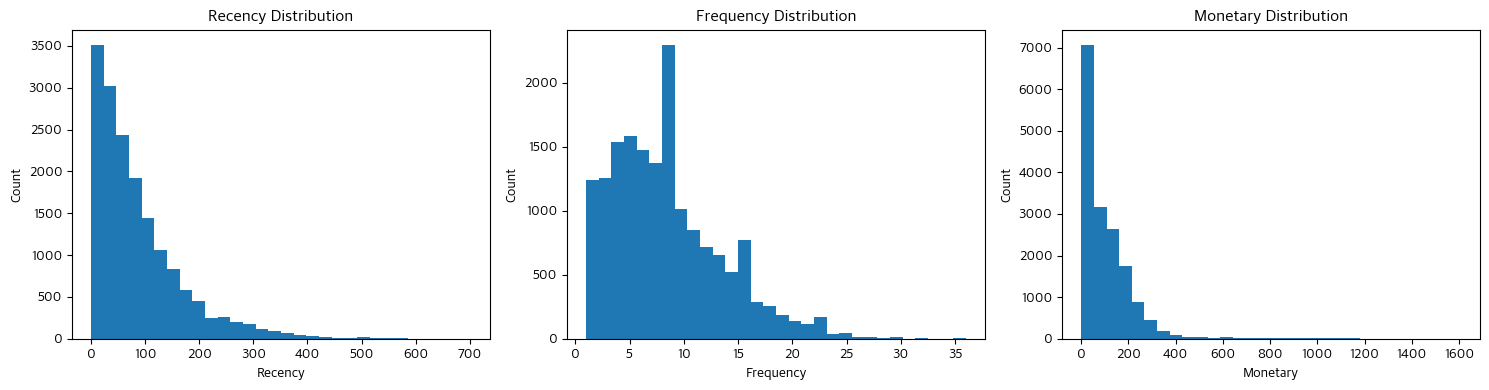

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4))

cols = ["Recency", "Frequency", "Monetary"]

for ax, col in zip(axes, cols):
    ax.hist(rfm[col], bins=30)
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

🔹 Recency 분포 (구매 최근성)

오른쪽으로 긴 꼬리를 가진 분포 (Right-skewed)
	•	다수 고객은 최근에 구매한 적이 있음
	•	하지만 소수 고객은 아주 오래 구매하지 않음
	•	즉,
	•	“활성 고객 + 장기 미활성 고객”이 강하게 공존
	•	평균은 의미 없음 → 최근성은 상대 비교가 중요

📌 의미

Recency는 “지금 다시 반응할 가능성”을 가르는 핵심 축
→ 절대값보다 상위/하위 구간으로 나눠야 함

⸻

🔹 Frequency 분포 (구매 빈도)

중간값 근처에 몰려 있지만, 꼬리가 김
	•	대부분 고객은 소수의 반복 구매
	•	일부 고객은 매우 잦은 구매 (헤비 유저)

📌 의미

Frequency는 고객 행동의 “습관성”을 나타냄
→ 상위 소수 고객이 전체 행동을 견인하는 구조

⸻

🔹 Monetary 분포 (누적 구매 금액)

극단적으로 치우친 분포 (강한 파레토 구조)
	•	대부분 고객은 낮은 누적 금액
	•	극소수 고객이 매출의 상당 부분을 차지

📌 의미

Monetary는 평균 기반 세그먼트가 완전히 무의미
→ 상위 몇 %를 분리하지 않으면 분석이 왜곡됨

이 분포에서 바로 나오는 결론 (중요)

❌ 하면 안 되는 접근
	•	평균 기준으로 High / Low 나누기
	•	R, F, M을 동일한 스케일로 바로 KMeans
	•	“전체 고객을 균등한 세그먼트”로 나누려는 시도

➡️ 왜?

분포가 비대칭인데, 대칭 가정(평균·분산)을 쓰면
“대부분 고객이 같은 군집”이 되어버림


/var/folders/dl/2hxyxgtd0vbcrnl54xbdbz7h0000gn/T/ipykernel_2445/2219151329.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


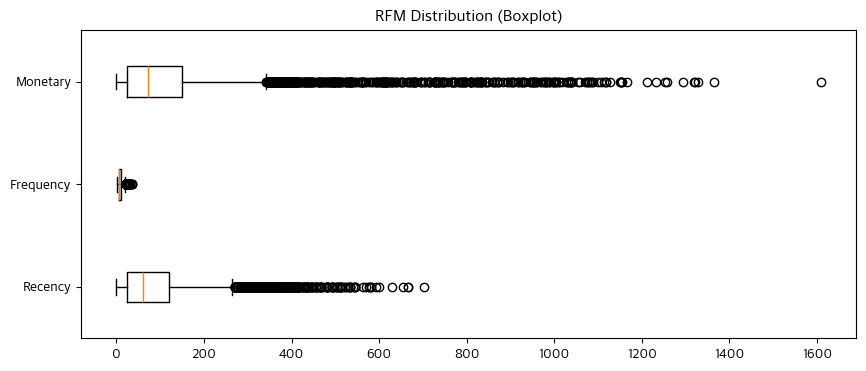

In [24]:
plt.figure(figsize=(10,4))
plt.boxplot(
    [rfm["Recency"], rfm["Frequency"], rfm["Monetary"]],
    labels=["Recency", "Frequency", "Monetary"],
    vert=False
)

plt.title("RFM Distribution (Boxplot)")
plt.show()

3️⃣ 이 분포에서 맞는 세그먼트 접근 전략

✅ Step 1. 순위 기반 스케일링이 필수

(이건 선택 아님)
	•	Recency → 낮을수록 좋음 → 역순
	•	Frequency, Monetary → 높을수록 좋음
	•	Quantile(5분위 or 4분위) 로 점수화

📌 이유

“이 고객이 얼마나 상대적으로 중요한가”가 핵심이지
“절대값이 얼마인가”가 아님

🚀 STEP 3. RFM 점수화 (분위수 방식)

KMeans 안 써도 됨
가이드라인 충족 + 설명 쉬움 = 분위수 점수

In [21]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 3, labels=[3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"], 3, labels=[1, 2, 3]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"], 3, labels=[1, 2, 3]).astype(int)

rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

rfm.head()

,person,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,0009655768c64bdeb2e877511632db8f,18,8,127.60,3,2,3,8
1,00116118485d4dfda04fdbaba9a87b5c,240,3,4.09,1,1,1,3
2,0011e0d4e6b944f998e987f904e8c1e5,60,5,79.46,2,1,2,5
3,0020c2b971eb4e9188eac86d93036a77,6,8,196.86,3,2,3,8
4,0020ccbbb6d84e358d3414a3ff76cffd,42,12,154.05,2,3,3,8


In [22]:
def assign_segment(score):
    if score >= 8:
        return "High Value"
    elif score >= 5:
        return "Mid Value"
    else:
        return "Low Value"

rfm["segment"] = rfm["RFM_score"].apply(assign_segment)

rfm["segment"].value_counts()

segment
Mid Value     8267
Low Value     4176
High Value    4135
Name: count, dtype: int64

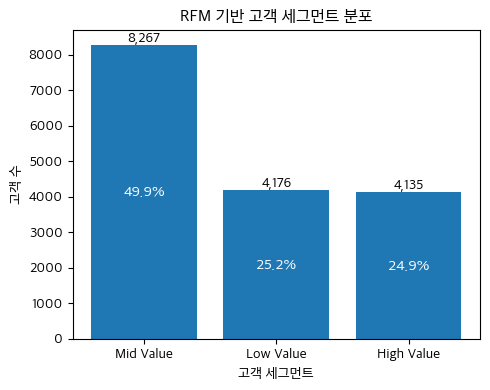

In [25]:
import matplotlib.pyplot as plt

# 세그먼트별 고객 수
seg_cnt = rfm["segment"].value_counts()
total_cnt = seg_cnt.sum()  # 전체 고객 수 (비중 계산용)

plt.figure(figsize=(5,4))
bars = plt.bar(seg_cnt.index, seg_cnt.values)

plt.title("RFM 기반 고객 세그먼트 분포")
plt.ylabel("고객 수")
plt.xlabel("고객 세그먼트")

# 바 위: 고객 수(건수)
# 바 안: 비중(%)
for i, v in enumerate(seg_cnt.values):
    ratio = v / total_cnt * 100  # 비중 계산
    
    # 바 안에 비중 (%), 흰색
    plt.text(
        i, v * 0.5,                # 바 중간쯤
        f"{ratio:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontsize=11,
        fontweight="bold"
    )
    
    # 바 위에 고객 수
    plt.text(
        i, v,
        f"{v:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## 📊 RFM 고객 세분화 결과

본 분석에서는 고객을 구매 최근성(Recency),
구매 빈도(Frequency), 누적 구매 금액(Monetary)을 기준으로 세분화하였다.

- High Value 고객은 최근에도 구매를 유지하고 있으며,
  구매 빈도와 누적 매출 기여도가 모두 높은 핵심 고객군이다.
- Low Value 고객은 구매 간격이 길고,
  구매 빈도와 매출 기여도가 상대적으로 낮은 그룹이다.

본 세그먼트는 이후 오퍼 실패 분석 결과와 결합하여,
어떤 고객군에 어떤 오퍼 전략이 적합한지 해석하는 기준으로 활용한다.

📊 비중으로 해석하면

(대략)
	•	Mid Value ≈ 49%
	•	Low Value ≈ 25%
	•	High Value ≈ 25%

📌 이 구조가 의미하는 것
	1.	고가치 고객은 소수지만 무시할 수 없는 규모
	2.	절반 가까운 고객이 ‘중간층’
	3.	“Low vs High”의 단순 이분법이 아님

⸻

✍️ 요약

전체 고객의 약 25%는 High Value 고객으로 분류되었으며,
이는 소수 핵심 고객에 매출이 집중되는 전형적인 파레토 구조를 반영한다.
동시에 약 절반에 해당하는 Mid Value 고객은
향후 가치 상승 또는 이탈 가능성이 공존하는 전략적 전환 구간으로 해석할 수 있다.